# How to Check Whether Data is Linear or Non-Linear

There are several methods.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

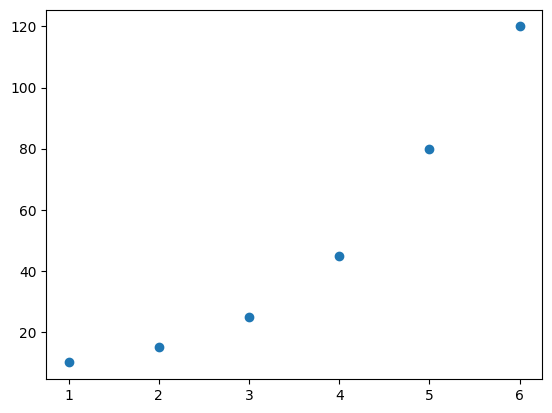

In [7]:
plt.scatter(df["Hours"],df["Marks"])
plt.show()

In [8]:
print(df.corr())

          Hours     Marks
Hours  1.000000  0.949627
Marks  0.949627  1.000000


| Correlation | Meaning                |
| ----------- | ---------------------- |
| 1           | Perfect Positive       |
| 0.8-0.99    | Very Strong            |
| 0.6-0.8     | Strong                 |
| 0.4-0.6     | Moderate               |
| 0.2-0.4     | Weak                   |
| 0           | No Linear Relationship |
| -1          | Perfect Negative       |


# Confusion Matrix

Suppose we are building a Machine Learning model that classifies an image as either:

Dog (Positive Class)
Cat (Negative Class)

Important: In binary classification, we must decide which class is Positive and which is Negative.

In this example:

Dog = Positive
Cat = Negative

| Image | Actual | Predicted |
| ----- | ------ | --------- |
| 1     | Dog    | Dog       |
| 2     | Dog    | Dog       |
| 3     | Dog    | Cat       |
| 4     | Dog    | Dog       |
| 5     | Cat    | Cat       |
| 6     | Cat    | Dog       |
| 7     | Cat    | Cat       |
| 8     | Cat    | Cat       |
| 9     | Dog    | Dog       |
| 10    | Cat    | Cat       |


|                | Predicted Dog | Predicted Cat |
| -------------- | ------------: | ------------: |
| **Actual Dog** |        TP = 4 |        FN = 1 |
| **Actual Cat** |        FP = 1 |        TN = 4 |


| Actual | Predicted | Result              |
| ------ | --------- | ------------------- |
| Dog    | Dog       | True Positive (TP)  |
| Dog    | Cat       | False Negative (FN) |
| Cat    | Dog       | False Positive (FP) |
| Cat    | Cat       | True Negative (TN)  |


# Precision
## Definition

Precision answers the question:

Out of all the images that the model predicted as Dog, how many were actually Dogs?

Formula
New Section
Precision=
TP+FP
TP
	​


Using our example

TP = 4

FP = 1

Precision=
4+1
4
	​

Precision=
5
4
	​

=0.80

Precision = 80%

## Interpretation

The model predicted 5 images as Dogs.

Out of those,

4 were actually Dogs.
1 was actually a Cat.

So,

80% of the Dog predictions were correct.

Higher precision means fewer false positives.

# Recall
## Definition

Recall answers:

Out of all the actual Dogs, how many did the model correctly identify?

Formula

Recall=
TP+FN
TP
	​


Using our example

TP = 4

FN = 1

Recall=
4+1
4
	​

Recall=0.80

Recall = 80%

# Interpretation

There were 5 actual Dogs.

The model correctly identified 4 Dogs.

It missed 1 Dog.

Hence,

Recall = 80%

Higher recall means fewer false negatives.

# Accuracy

Accuracy answers:

Out of all predictions, how many were correct?

Formula

Accuracy=
TP+TN+FP+FN
TP+TN
	​


Our values

TP = 4

TN = 4

FP = 1

FN = 1

Accuracy=
4+4+1+1
4+4
	​

Accuracy=
10
8
	​


Accuracy = 80%

## Interpretation

There were 10 images.

The model classified 8 correctly.

Accuracy = 80%

# F1 Score

Sometimes Precision is high but Recall is low.

Sometimes Recall is high but Precision is low.

We need one metric that balances both.

That metric is the F1 Score.

Formula

F1=2×
Precision+Recall
Precision×Recall
	​


Our values

Precision = 0.80

Recall = 0.80

F1=2×
0.8+0.8
0.8×0.8
	​

F1=0.80

F1 Score = 80%

Confusion Matrix:
[[4 1]
 [1 4]]

Accuracy : 0.8
Precision: 0.8
Recall   : 0.8
F1 Score : 0.8


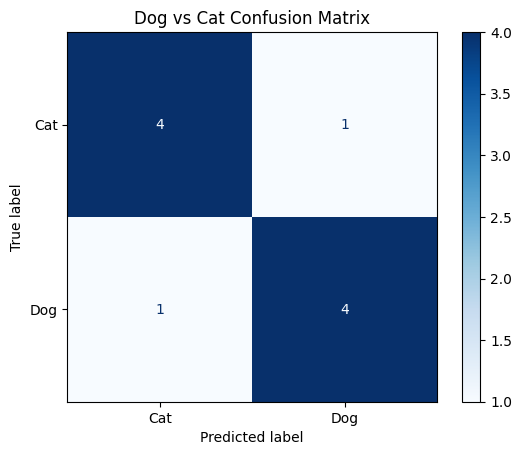

In [10]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Dog = Positive (1)
# Cat = Negative (0)

actual =    [1,1,1,1,0,0,0,0,1,0]
predicted = [1,1,0,1,0,1,0,0,1,0]

# Confusion Matrix
cm = confusion_matrix(actual, predicted)

print("Confusion Matrix:")
print(cm)

# Metrics
accuracy = accuracy_score(actual, predicted)
precision = precision_score(actual, predicted)
recall = recall_score(actual, predicted)
f1 = f1_score(actual, predicted)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Plot Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
).plot(cmap="Blues")

plt.title("Dog vs Cat Confusion Matrix")
plt.show()

# What is Polynomial Regression?

Polynomial Regression is an extension of Linear Regression that is used when the relationship between the independent variable (X) and dependent variable (Y) is non-linear.

## Linear Regression

Linear Regression fits a straight line.
| Hours | Marks |
| ----- | ----- |
| 1     | 20    |
| 2     | 40    |
| 3     | 60    |
| 4     | 80    |

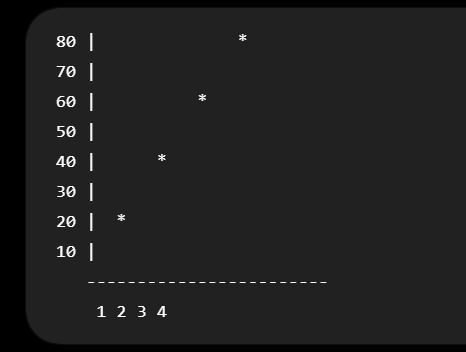

## Polynomial Regression

Suppose marks increase slowly at first and then rapidly.
| Study Hours | Marks |
| ----------- | ----- |
| 1           | 10    |
| 2           | 15    |
| 3           | 25    |
| 4           | 45    |
| 5           | 80    |
| 6           | 120   |

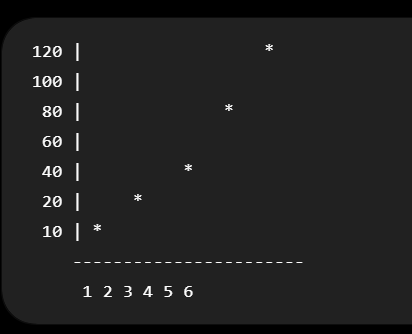




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
data = {
    "Hours":[1,2,3,4,5,6],
    "Marks":[10,15,25,45,80,120]
}

df = pd.DataFrame(data)

print(df)

   Hours  Marks
0      1     10
1      2     15
2      3     25
3      4     45
4      5     80
5      6    120


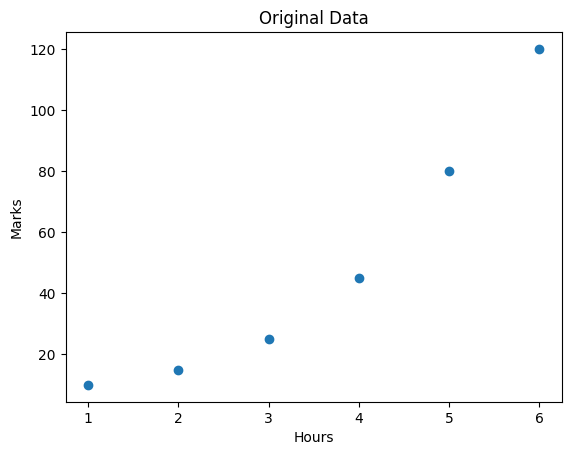

In [3]:
plt.scatter(df["Hours"],df["Marks"])
plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Original Data")
plt.show()

In [4]:
X = df[["Hours"]]
y = df["Marks"]

In [5]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

print(X_poly)

[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]
 [ 1.  6. 36.]]


In [6]:
model = LinearRegression()

model.fit(X_poly,y)

LinearRegression()

In [ ]:
predictions = model.predict(X_poly)

print(predictions)

In [ ]:
plt.scatter(X,y,color="red")

plt.plot(X,predictions,color="blue")

plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Polynomial Regression")

plt.show()

In [ ]:
new_data = poly.transform([[7]])

prediction = model.predict(new_data)

print(prediction)